In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('/content/full_grouped.csv')
df

,Date,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,WHO Region
0,2020-01-22,Afghanistan,0,0,0,0,0,0,0,Eastern Mediterranean
1,2020-01-22,Albania,0,0,0,0,0,0,0,Europe
2,2020-01-22,Algeria,0,0,0,0,0,0,0,Africa
3,2020-01-22,Andorra,0,0,0,0,0,0,0,Europe
4,2020-01-22,Angola,0,0,0,0,0,0,0,Africa
...,...,...,...,...,...,...,...,...,...,...
35151,2020-07-27,West Bank and Gaza,10621,78,3752,6791,152,2,0,Eastern Mediterranean
35152,2020-07-27,Western Sahara,10,1,8,1,0,0,0,Africa
35153,2020-07-27,Yemen,1691,483,833,375,10,4,36,Eastern Mediterranean
35154,2020-07-27,Zambia,4552,140,2815,1597,71,1,465,Africa


In [4]:
df.shape

(35156, 10)

In [5]:
df.head()

,Date,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,WHO Region
0,2020-01-22,Afghanistan,0,0,0,0,0,0,0,Eastern Mediterranean
1,2020-01-22,Albania,0,0,0,0,0,0,0,Europe
2,2020-01-22,Algeria,0,0,0,0,0,0,0,Africa
3,2020-01-22,Andorra,0,0,0,0,0,0,0,Europe
4,2020-01-22,Angola,0,0,0,0,0,0,0,Africa


In [6]:
df.columns.tolist()

['Date',
 'Country/Region',
 'Confirmed',
 'Deaths',
 'Recovered',
 'Active',
 'New cases',
 'New deaths',
 'New recovered',
 'WHO Region']

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35156 entries, 0 to 35155
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Date            35156 non-null  object
 1   Country/Region  35156 non-null  object
 2   Confirmed       35156 non-null  int64 
 3   Deaths          35156 non-null  int64 
 4   Recovered       35156 non-null  int64 
 5   Active          35156 non-null  int64 
 6   New cases       35156 non-null  int64 
 7   New deaths      35156 non-null  int64 
 8   New recovered   35156 non-null  int64 
 9   WHO Region      35156 non-null  object
dtypes: int64(7), object(3)
memory usage: 2.7+ MB


In [8]:
df.isnull().sum()

,0
Date,0
Country/Region,0
Confirmed,0
Deaths,0
Recovered,0
Active,0
New cases,0
New deaths,0
New recovered,0
WHO Region,0


In [9]:
df['Data']=pd.to_datetime(df['Date'])
df

,Date,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,WHO Region,Data
0,2020-01-22,Afghanistan,0,0,0,0,0,0,0,Eastern Mediterranean,2020-01-22
1,2020-01-22,Albania,0,0,0,0,0,0,0,Europe,2020-01-22
2,2020-01-22,Algeria,0,0,0,0,0,0,0,Africa,2020-01-22
3,2020-01-22,Andorra,0,0,0,0,0,0,0,Europe,2020-01-22
4,2020-01-22,Angola,0,0,0,0,0,0,0,Africa,2020-01-22
...,...,...,...,...,...,...,...,...,...,...,...
35151,2020-07-27,West Bank and Gaza,10621,78,3752,6791,152,2,0,Eastern Mediterranean,2020-07-27
35152,2020-07-27,Western Sahara,10,1,8,1,0,0,0,Africa,2020-07-27
35153,2020-07-27,Yemen,1691,483,833,375,10,4,36,Eastern Mediterranean,2020-07-27
35154,2020-07-27,Zambia,4552,140,2815,1597,71,1,465,Africa,2020-07-27


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.describe()

,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Data
count,3.515600e+04,35156.000000,3.515600e+04,3.515600e+04,35156.00000,35156.000000,35156.000000,35156
mean,2.356663e+04,1234.068239,1.104813e+04,1.128443e+04,469.36375,18.603339,269.315593,2020-04-24 12:00:00
min,0.000000e+00,0.000000,0.000000e+00,-2.000000e+00,0.00000,-1918.000000,-16298.000000,2020-01-22 00:00:00
25%,1.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.00000,0.000000,0.000000,2020-03-08 18:00:00
50%,2.500000e+02,4.000000,3.300000e+01,8.500000e+01,2.00000,0.000000,0.000000,2020-04-24 12:00:00
75%,3.640250e+03,78.250000,1.286250e+03,1.454000e+03,75.00000,1.000000,20.000000,2020-06-10 06:00:00
max,4.290259e+06,148011.000000,1.846641e+06,2.816444e+06,77255.00000,3887.000000,140050.000000,2020-07-27 00:00:00
std,1.499818e+05,7437.238354,6.454640e+04,8.997149e+04,3005.86754,115.706351,2068.063852,NaN


In [14]:
latest = df.loc[df['Data'] == max(df['Data'])]
latest
latest['Confirmed'].sum()

np.int64(16480485)

In [15]:
latest['Deaths'].sum()

np.int64(654036)

In [16]:
latest['Recovered'].sum()

np.int64(9468087)

In [17]:
latest['Active'].sum()

np.int64(6358362)

In [18]:
top_countries = latest.groupby('Country/Region')['Confirmed'].sum().sort_values(ascending=False).head(10)
top_countries

,Confirmed
Country/Region,
US,4290259
Brazil,2442375
India,1480073
Russia,816680
South Africa,452529
Mexico,395489
Peru,389717
Chile,347923
United Kingdom,301708


In [20]:
daily_confirmed = df.groupby('Data')['New cases'].sum()
daily_confirmed

,New cases
Data,
2020-01-22,0
2020-01-23,99
2020-01-24,287
2020-01-25,493
2020-01-26,684
...,...
2020-07-23,282756
2020-07-24,281164
2020-07-25,255545


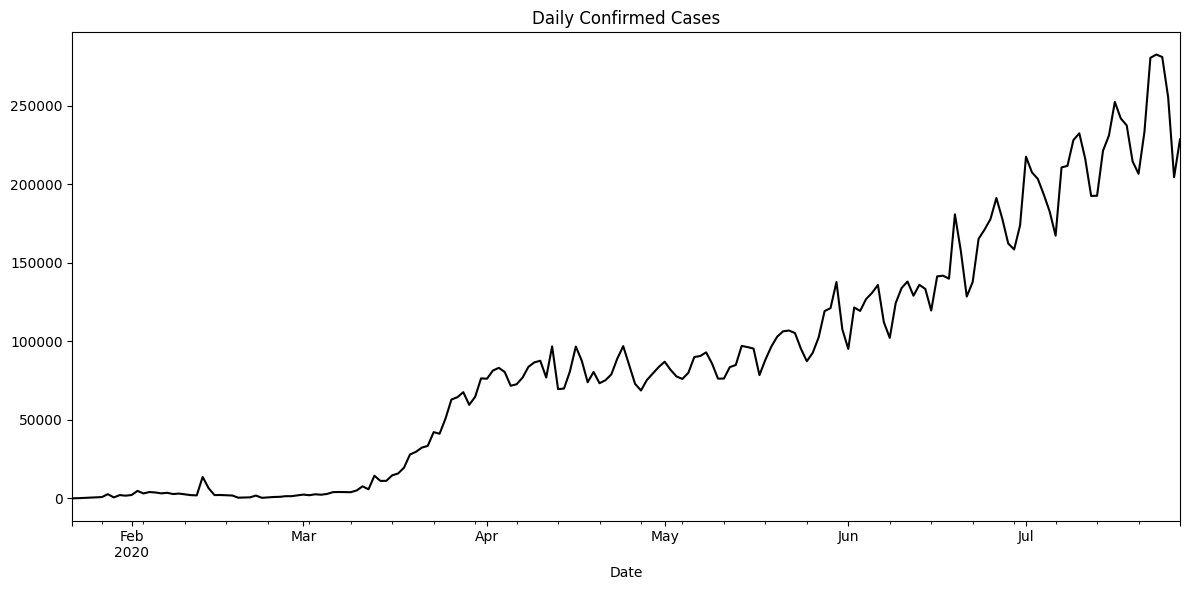

In [21]:
daily_confirmed.plot(kind='line', figsize=(12, 6), title='Daily Confirmed Cases', color='k')
plt.xlabel('Date')
plt.title('Daily Confirmed Cases')
plt.tight_layout()
plt.show()

In [24]:
latest_global=df[df['Date']==df['Date'].max()]
latest_global

,Date,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,WHO Region,Data
34969,2020-07-27,Afghanistan,36263,1269,25198,9796,106,10,18,Eastern Mediterranean,2020-07-27
34970,2020-07-27,Albania,4880,144,2745,1991,117,6,63,Europe,2020-07-27
34971,2020-07-27,Algeria,27973,1163,18837,7973,616,8,749,Africa,2020-07-27
34972,2020-07-27,Andorra,907,52,803,52,10,0,0,Europe,2020-07-27
34973,2020-07-27,Angola,950,41,242,667,18,1,0,Africa,2020-07-27
...,...,...,...,...,...,...,...,...,...,...,...
35151,2020-07-27,West Bank and Gaza,10621,78,3752,6791,152,2,0,Eastern Mediterranean,2020-07-27
35152,2020-07-27,Western Sahara,10,1,8,1,0,0,0,Africa,2020-07-27
35153,2020-07-27,Yemen,1691,483,833,375,10,4,36,Eastern Mediterranean,2020-07-27
35154,2020-07-27,Zambia,4552,140,2815,1597,71,1,465,Africa,2020-07-27


In [28]:
total_confirmed=latest_global['Confirmed'].sum()
total_deaths=latest_global['Deaths'].sum()
total_recovered=latest_global['Recovered'].sum()
total_active=latest_global['Active'].sum()

death_rate=(total_deaths/total_confirmed)*100
recovery_rate=(total_recovered/total_confirmed)*100

(f"Death Rate: {death_rate:.2f}%")

'Death Rate: 3.97%'

In [29]:
(f"Recovery Rate: {recovery_rate:.2f}%")

'Recovery Rate: 57.45%'

/tmp/ipykernel_4911/1248295591.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values,y=top_countries.index,palette='Reds_r')


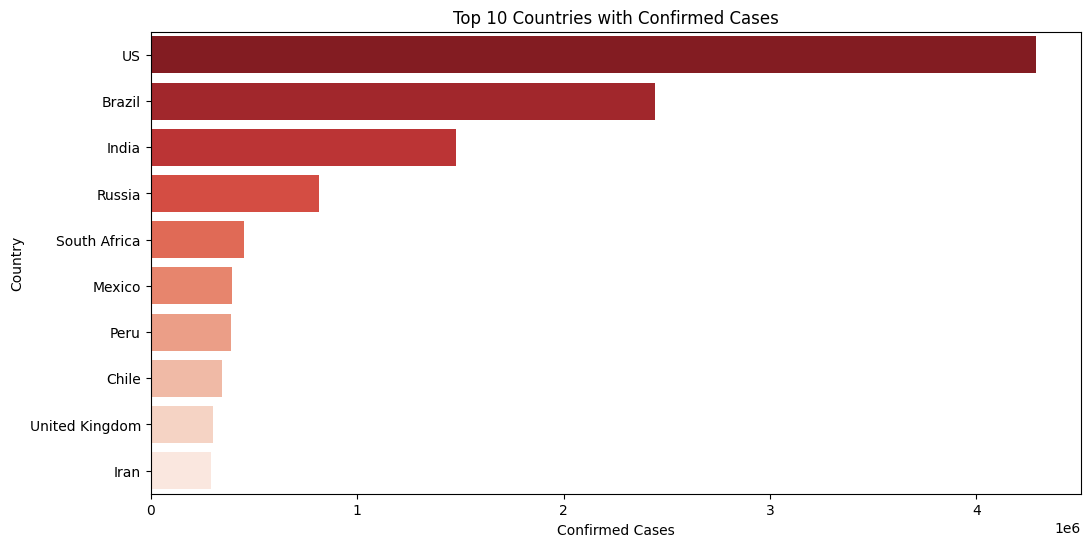

In [31]:
plt.figure(figsize=(12, 6))
sns.barplot(x=top_countries.values,y=top_countries.index,palette='Reds_r')
plt.title('Top 10 Countries with Confirmed Cases')
plt.xlabel('Confirmed Cases')
plt.ylabel('Country')
plt.show()

In [32]:
region_data=latest.groupby('WHO Region')['Confirmed'].sum().sort_values(ascending=False)
region_data

,Confirmed
WHO Region,
Americas,8839286
Europe,3299523
South-East Asia,1835297
Eastern Mediterranean,1490744
Africa,723207
Western Pacific,292428


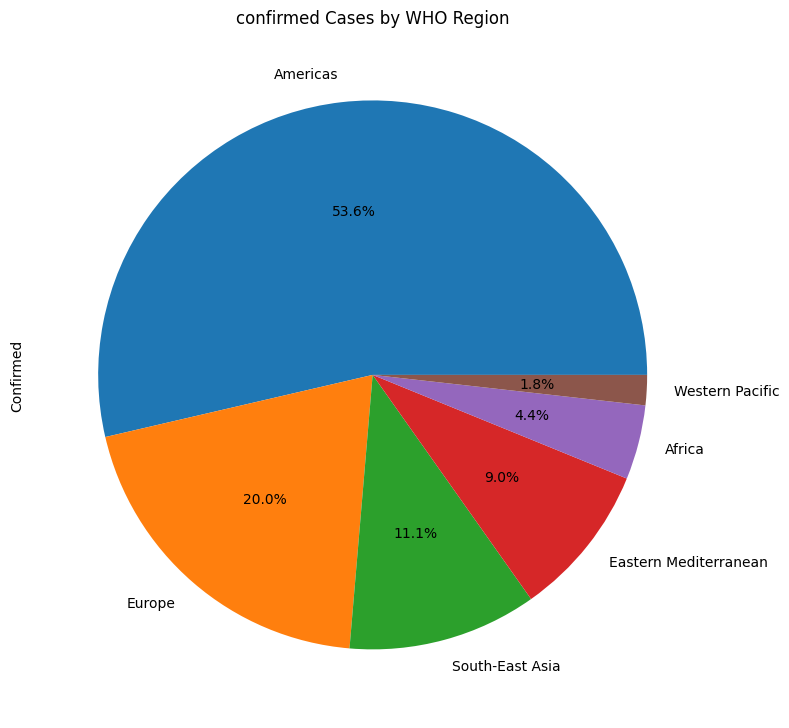

In [34]:
region_data.plot(kind='pie',figsize=(8,8),title='confirmed Cases by WHO Region', autopct='%1.1f%%')
plt.tight_layout()
plt.show()